# 从零实现 ResNet，并应用到 MNIST

这个 notebook 不调用 `torchvision.models.resnet18`，而是从头实现：

1. `3×3` 和 `1×1` 卷积辅助函数；
2. `BasicBlock` 残差块；
3. `_make_layer()` 组装残差阶段；
4. 完整的 `ResNet` 类；
5. MNIST 数据加载、训练、评估和单张预测。

本实现是 **ResNet-18 结构**，但针对 MNIST 做了两点调整：输入是 1 通道；28×28 图片较小，因此开头使用 `3×3, stride=1`，并去掉 ImageNet 版开头的最大池化。

## 1. 导入库并选择计算设备

当前项目的 `dl` 环境同时包含两份 OpenMP 运行库。下面第一行兼容设置沿用本项目已有 notebook；长期更稳妥的做法是重新整理环境，让 PyTorch 只链接一份 OpenMP。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # 仅兼容当前本地 dl 环境

import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.13.0
Device: mps


## 2. 准备 MNIST 数据

每张 MNIST 图片的原始 shape 是 `[1, 28, 28]`：1 个灰度通道，高和宽都是 28。`Normalize` 使用 MNIST 常见的均值 `0.1307` 和标准差 `0.3081`。

In [2]:
DATA_DIR = Path("data")
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(
    root=DATA_DIR, train=True, download=False, transform=transform
)
test_dataset = datasets.MNIST(
    root=DATA_DIR, train=False, download=False, transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

images, labels = next(iter(train_loader))
print("训练集大小:", len(train_dataset))
print("测试集大小:", len(test_dataset))
print("一个 batch 的图片 shape:", images.shape)
print("一个 batch 的标签 shape:", labels.shape)

训练集大小: 60000
测试集大小: 10000
一个 batch 的图片 shape: torch.Size([128, 1, 28, 28])
一个 batch 的标签 shape: torch.Size([128])


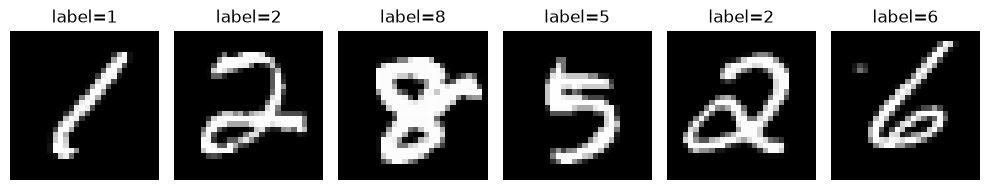

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for index, axis in enumerate(axes):
    # 反归一化只用于显示，不参与训练
    image = images[index].squeeze(0) * 0.3081 + 0.1307
    axis.imshow(image, cmap="gray")
    axis.set_title(f"label={labels[index].item()}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## 3. 定义卷积辅助函数

- `conv3x3`：残差主分支使用，观察当前位置周围的局部区域；当 `stride=1, padding=1` 时宽高不变。
- `conv1x1`：捷径分支使用，在 shape 不匹配时调整通道数，并可用 `stride=2` 缩小宽高。
- 卷积后紧跟 BatchNorm，因此卷积本身不需要 bias。

In [4]:
def conv3x3(in_channels, out_channels, stride=1):
    """3×3 卷积：padding=1，使 stride=1 时宽高保持不变。"""
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False,
    )


def conv1x1(in_channels, out_channels, stride=1):
    """1×1 卷积：调整通道数；stride=2 时同时缩小宽高。"""
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        bias=False,
    )

## 4. 实现 BasicBlock

一个基础残差块有两条路：

```text
主分支：x → 3×3 → BN → ReLU → 3×3 → BN → F(x)
捷径：  x ───────────────────────────────→ identity
最后：  F(x) + identity → ReLU
```

当主分支改变了宽高或通道数，捷径必须通过 `downsample` 调整成相同 shape，才能逐元素相加。

In [5]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = conv3x3(in_channels, channels, stride=stride)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = conv3x3(channels, channels, stride=1)
        self.bn2 = nn.BatchNorm2d(channels)

        self.downsample = downsample

    def forward(self, x):
        # 先保存捷径分支。若 shape 不变，它就是原输入 x。
        identity = x

        # 主分支学习残差 F(x)。
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 如果宽高或通道不同，使用 1×1 卷积调整捷径。
        if self.downsample is not None:
            identity = self.downsample(x)

        # ResNet 最关键的一行：y = F(x) + x。
        out = out + identity
        out = self.relu(out)

        return out

## 5. 实现完整 ResNet 类

`_make_layer()` 的规则：每个 stage 的第一个 block 可能负责降采样和增加通道，后面的 block 保持 shape。

MNIST 的 shape 路线：

```text
[N, 1, 28, 28]
→ stem   [N, 16, 28, 28]
→ layer1 [N, 16, 28, 28]
→ layer2 [N, 32, 14, 14]
→ layer3 [N, 64,  7,  7]
→ layer4 [N,128,  4,  4]
→ avgpool[N,128,  1,  1]
→ flatten[N,128]
→ fc     [N,10]
```

In [6]:
class ResNet(nn.Module):
    def __init__(
        self,
        block,
        layers,
        num_classes=10,
        in_channels=1,
        base_channels=16,
        zero_init_residual=True,
    ):
        super().__init__()

        # self.in_channels 记录“当前张量有多少个通道”，会被 _make_layer 更新。
        self.in_channels = base_channels

        # MNIST 只有 28×28，因此不用 ImageNet 版的 7×7 stride=2 + maxpool。
        self.conv1 = nn.Conv2d(
            in_channels, base_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(base_channels)
        self.relu = nn.ReLU(inplace=True)

        # 四个 stage 分别使用 base、2×base、4×base、8×base 个通道。
        self.layer1 = self._make_layer(block, base_channels, layers[0], stride=1)
        self.layer2 = self._make_layer(block, base_channels * 2, layers[1], stride=2)
        self.layer3 = self._make_layer(block, base_channels * 4, layers[2], stride=2)
        self.layer4 = self._make_layer(block, base_channels * 8, layers[3], stride=2)

        # 不管输入特征图多大，都压缩成 1×1。
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(base_channels * 8 * block.expansion, num_classes)

        self._initialize_weights()

        # 让每个残差分支起步时更接近 0，整个 block 起步时更接近 identity。
        if zero_init_residual:
            for module in self.modules():
                if isinstance(module, BasicBlock):
                    nn.init.constant_(module.bn2.weight, 0)

    def _make_layer(self, block, channels, num_blocks, stride):
        out_channels = channels * block.expansion
        downsample = None

        # 只要空间尺寸或通道数对不上，就调整捷径分支。
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                conv1x1(self.in_channels, out_channels, stride=stride),
                nn.BatchNorm2d(out_channels),
            )

        blocks = []

        # 每个 stage 的第一个 block 可能改变宽高和通道数。
        blocks.append(
            block(
                in_channels=self.in_channels,
                channels=channels,
                stride=stride,
                downsample=downsample,
            )
        )

        # 第一个 block 之后，当前通道数已经变成 out_channels。
        self.in_channels = out_channels

        # 同一 stage 的其余 block 不再改变 shape。
        for _ in range(1, num_blocks):
            blocks.append(
                block(
                    in_channels=self.in_channels,
                    channels=channels,
                    stride=1,
                    downsample=None,
                )
            )

        return nn.Sequential(*blocks)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # 四个残差 stage
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # 分类头
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # 保留 batch 维，从 channel 维开始展平
        logits = self.fc(x)

        # 返回 logits，不在模型内部做 softmax。
        return logits

## 6. 创建 ResNet-18

`[2, 2, 2, 2]` 表示四个 stage 各有两个 BasicBlock。卷积层计数为 `1 + 2×(2+2+2+2) = 17`，再加最后的全连接层，就是 ResNet-18。捷径上的投影卷积不计入这个命名层数。

这里用 `base_channels=16` 让 MNIST 训练更轻量。如果想使用标准 ResNet-18 的宽度，可改为 `64`。

In [7]:
def resnet18_mnist(num_classes=10, base_channels=16):
    return ResNet(
        block=BasicBlock,
        layers=[2, 2, 2, 2],
        num_classes=num_classes,
        in_channels=1,
        base_channels=base_channels,
    )


model = resnet18_mnist(num_classes=10, base_channels=16).to(device)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(model)
print(f"可训练参数量: {trainable_parameters:,}")

ResNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 

## 7. 用 forward hook 验证每一阶段的 shape

Hook 不改变模型，只在指定层运行结束时打印输出 shape。

In [8]:
def print_shape(name):
    def hook(module, inputs, output):
        print(f"{name:8s} -> {tuple(output.shape)}")
    return hook


watched_layers = {
    "conv1": model.conv1,
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4,
    "avgpool": model.avgpool,
    "fc": model.fc,
}

handles = [layer.register_forward_hook(print_shape(name)) for name, layer in watched_layers.items()]

model.eval()
dummy_input = torch.randn(2, 1, 28, 28, device=device)
with torch.no_grad():
    dummy_logits = model(dummy_input)

for handle in handles:
    handle.remove()

print("最终 logits shape:", tuple(dummy_logits.shape))

conv1    -> (2, 16, 28, 28)
layer1   -> (2, 16, 28, 28)
layer2   -> (2, 32, 14, 14)
layer3   -> (2, 64, 7, 7)
layer4   -> (2, 128, 4, 4)
avgpool  -> (2, 128, 1, 1)
fc       -> (2, 10)
最终 logits shape: (2, 10)


## 8. 定义损失函数、优化器和训练函数

模型输出的是 logits。`CrossEntropyLoss` 会直接接收 logits，因此训练时不要先手动执行 Softmax。

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)


def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

## 9. 开始训练

默认训练 2 个 epoch，足够验证整条流程。想获得更高准确率时可增加到 5～10。

In [10]:
EPOCHS = 2
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}

for epoch in range(1, EPOCHS + 1):
    start_time = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_accuracy = evaluate(
        model, test_loader, criterion, device
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    elapsed = time.perf_counter() - start_time
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, acc {train_accuracy:.2%} | "
        f"test loss {test_loss:.4f}, acc {test_accuracy:.2%} | "
        f"{elapsed:.1f}s"
    )

Epoch 01/2 | train loss 0.3906, acc 89.57% | test loss 0.0541, acc 98.23% | 16.2s


Epoch 02/2 | train loss 0.0371, acc 98.96% | test loss 0.0431, acc 98.63% | 15.0s


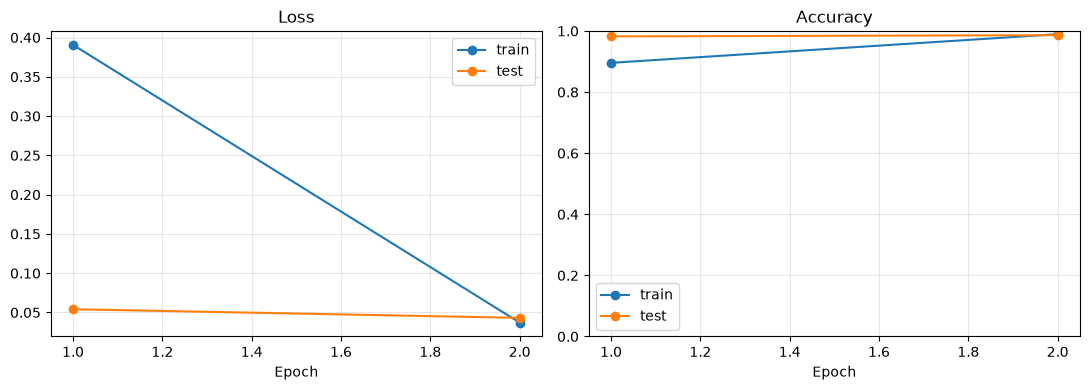

In [11]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["test_loss"], marker="o", label="test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="train")
axes[1].plot(epochs, history["test_accuracy"], marker="o", label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 对单张图片进行预测

训练时直接把 logits 交给交叉熵；这里只是为了展示概率，才调用 Softmax。

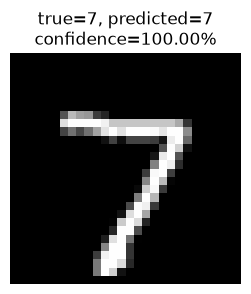

10 个类别的概率:
  0: 0.0001%
  1: 0.0010%
  2: 0.0011%
  3: 0.0006%
  4: 0.0002%
  5: 0.0001%
  6: 0.0000%
  7: 99.9958%
  8: 0.0000%
  9: 0.0010%


In [12]:
model.eval()
image, true_label = test_dataset[0]

with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))
    probabilities = torch.softmax(logits, dim=1)
    predicted_label = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_label].item()

display_image = image.squeeze(0) * 0.3081 + 0.1307
plt.figure(figsize=(3, 3))
plt.imshow(display_image, cmap="gray")
plt.title(
    f"true={true_label}, predicted={predicted_label}\nconfidence={confidence:.2%}"
)
plt.axis("off")
plt.show()

print("10 个类别的概率:")
for digit, probability in enumerate(probabilities.squeeze(0).cpu().tolist()):
    print(f"  {digit}: {probability:.4%}")

## 11. 回顾

完整数据流是：

```text
MNIST 图片
→ stem 提取初级特征
→ layer1 保持 28×28
→ layer2/3/4 逐步缩小空间、增加通道
→ AdaptiveAvgPool 把每个通道压成一个数字
→ Linear 输出 10 个 logits
→ CrossEntropyLoss 训练 / Softmax 展示概率
```

ResNet 最核心的代码仍然只有一行：`out = out + identity`。